# Volatility Skew Analysis using NIFTY Option Chain

---


## Objective :


To analyze the implied volatility (IV) structure across strike prices for NIFTY options as of 17th April 2025 with expiry on 30th April 2025. The goal is to compute IVs using the Black-Scholes model and visualize the volatility skew for calls and puts.

---


## Methodology :

- Data Collection:

  - Option chain data was collected for NIFTY options on 17th April 2025 for expiry on 30th April 2025.

- Fields used: strike price, last traded price (LTP) of call and put options.

- Assumptions:

    - Spot Price (S) = 23851 (NIFTY closing price on 17th April)

    - Risk-free Rate (r) = 6% annualized 

    - Time to Maturity (T) = 14 days (17 th April to 30 th April)

- Steps:

    - Load the dataset.

    - Define the Black-Scholes pricing model.

    - Implement Newton-Raphson method to compute implied volatility.

    - Calculate IVs for each strike for both calls and puts.

    - Plot the IV skew across strike prices.

---


##  Key Findings :

- The plot indicates that Put IVs are generally higher than Call IVs, which is consistent with typical market skew behavior in equity indices.

- There is no perfect volatility smile or skew due to irregularities and noise in option prices - this reflects real-world data behavior.

- Spot price intersects around the minimum IV region, consistent with the ATM option being most liquid.

---


## Conclusion :

This project successfully demonstrates the process of calculating implied volatility and plotting the volatility skew for NIFTY options using the Black-Scholes model. It also shows how real-world data can deviate from theoretical expectations, necessitating data cleaning and interpretation care.

---


## Code and analysis :

Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm


Black Scholes model

In [2]:
def black_scholes(S, K, r, T, sigma, option_type="call"):
    d1 = (np.log(S / K) + (r + 0.5 * (sigma**2)) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    elif option_type == 'put':
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)
        

Implied volatility (via Newton Raphson method)

In [3]:
def implied_vol(market_price, S, K, r, T, option_type="call", tol=1e-6,  max_iter=100):
    sigma = 0.15
    for _ in range(max_iter):
        
        price = black_scholes(S, K, r, T, sigma,option_type)
        diff = price - market_price
        if abs(diff) < tol:
            return sigma * 100

        d1 = (np.log(S/K) + (r + 0.5 * (sigma**2)) * T) / (sigma * np.sqrt(T))
        vega = S * np.sqrt(T) * (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * (d1**2))
        
        if vega < 1e-8:
            return None

        sigma = sigma - diff / vega
        sigma = max(sigma, 1e-4)
    return None
    

Load option data

In [4]:
df=pd.read_csv("option_price_data_17Apr-30Apr.csv")
df

,strike_price,call (LTP),put (LTP)
0,23050.0,878.85,55.00
1,23100.0,820.70,60.00
2,23150.0,782.00,67.25
3,23200.0,736.60,75.00
4,23250.0,680.60,82.00
5,23300.0,654.50,91.00
6,23350.0,622.30,100.65
7,23400.0,584.90,107.55
8,23450.0,543.90,117.00
9,23500.0,494.15,126.00


Parameters

In [5]:
spot_price = 23851
risk_free_rate = 0.06
maturity_time = 14/365


Calculate implied volatility

In [6]:
call_iv = []
put_iv = []
for i in range(len(df)):
    call_iv.append( implied_vol( df["call (LTP)"].iloc[i], spot_price, df["strike_price"].iloc[i], risk_free_rate, maturity_time, "call"))
    put_iv.append( implied_vol( df["put (LTP)"].iloc[i], spot_price, df["strike_price"].iloc[i], risk_free_rate, maturity_time, "put"))
    

Plot implied volatility skew

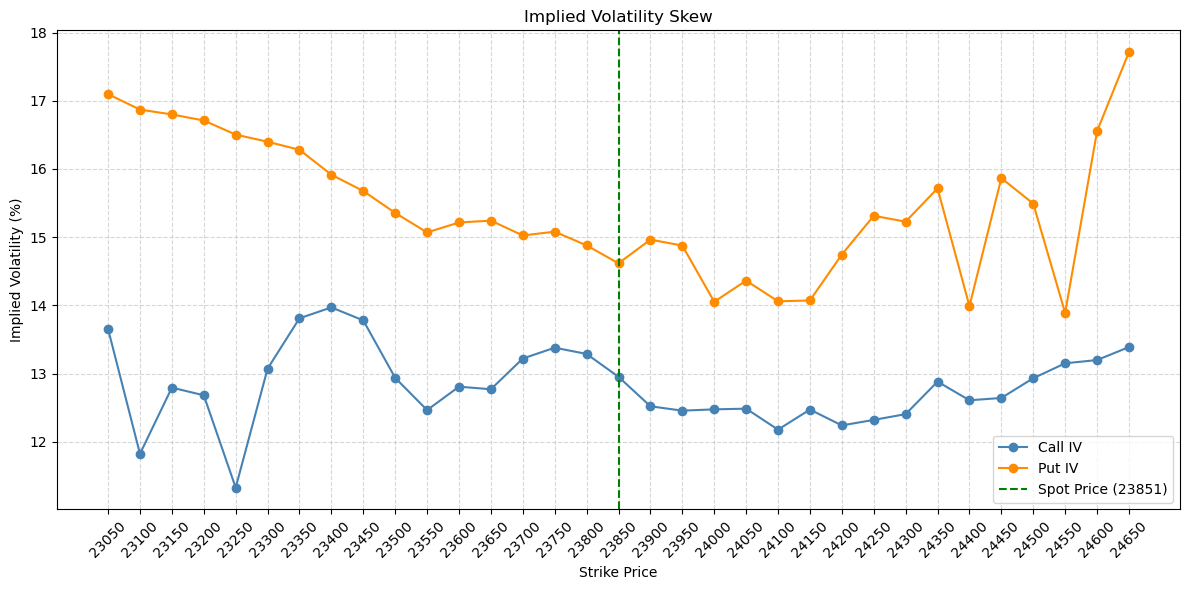

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(df["strike_price"], call_iv, label="Call IV", marker='o', linestyle='-', color='steelblue')
plt.plot(df["strike_price"], put_iv, label="Put IV", marker='o', linestyle='-', color='darkorange')
plt.axvline(x=spot_price, color='green', linestyle='--', linewidth=1.5, label=f"Spot Price ({spot_price})")

plt.title("Implied Volatility Skew")
plt.xlabel("Strike Price")
plt.ylabel("Implied Volatility (%)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(df["strike_price"], rotation=45)  # Show all strike prices with rotation
plt.legend()
plt.tight_layout()

#plt.savefig("volatility_skew.png", dpi=300)
plt.show()
